In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

# Ensure project files are discoverable
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.evaluation import print_metrics, plot_confusion

2026-03-20 22:32:34.588979: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-20 22:32:34.593232: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-20 22:32:34.779356: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-20 22:32:36.073712: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
# Load the pre-processed data
processed_dir = Path("../data/processed")

# We saved as CSV, so we load using pandas
X_train_df = pd.read_csv(processed_dir / "X_train.csv")
X_test_df = pd.read_csv(processed_dir / "X_test.csv")
y_train_df = pd.read_csv(processed_dir / "y_train.csv")["label"]
y_test_df = pd.read_csv(processed_dir / "y_test.csv")["label"]

# Convert our binary labels to one-hot categorical format to match CNN softmax output
y_train = to_categorical(y_train_df)
y_test = to_categorical(y_test_df)

# A Conv1D layer expects a 3D input tensor of shape: (batch_size, steps, features)
# Here, steps = num_features, and features = 1
X_train = np.expand_dims(X_train_df.values, axis=-1)
X_test = np.expand_dims(X_test_df.values, axis=-1)

print(f"X_train CNN shape: {X_train.shape}")
print(f"y_train CNN shape: {y_train.shape}")
print(f"X_test CNN shape: {X_test.shape}")
print(f"y_test CNN shape: {y_test.shape}")

X_train CNN shape: (107842, 20, 1)
y_train CNN shape: (107842, 2)
X_test CNN shape: (25195, 20, 1)
y_test CNN shape: (25195, 2)


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

print("Building 1D CNN for tabular data...")
model = Sequential()

# Feature shape = (number_of_features, 1)
model.add(Conv1D(64, 3, activation='relu', input_shape=(X_train.shape[1], 1)))
model.add(MaxPooling1D(2))
model.add(Dropout(0.3))

model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(y_train.shape[1], activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Building 1D CNN for tabular data...


/home/samad/DS_project/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-20 22:32:42.624402: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 18, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 9, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 9, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,314 (145.76 KB)

 Trainable params: 37,314 (145.76 KB)

 Non-trainable params: 0 (0.00 B)

Training 1D CNN Model...
Epoch 1/10
1686/1686 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9688 - loss: 0.0999 - val_accuracy: 0.9757 - val_loss: 0.0748
Epoch 2/10
1686/1686 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9757 - loss: 0.0744 - val_accuracy: 0.9770 - val_loss: 0.0688
Epoch 3/10
1686/1686 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9774 - loss: 0.0657 - val_accuracy: 0.9753 - val_loss: 0.0661
Epoch 4/10
1686/1686 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9792 - loss: 0.0602 - val_accuracy: 0.9808 - val_loss: 0.0573
Epoch 5/10
1686/1686 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9803 - loss: 0.0563 - val_accuracy: 0.9790 - val_loss: 0.0563
Epoch 6/10
1686/1686 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9812 - loss: 0.0532 - val_accuracy: 0.9826 - val_loss: 0.0514
Epoch 7/10
1686/1686 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9822 - loss: 0.0508 - val_accuracy: 0.9829 - val_loss: 0.0491
Epoch 8/10
1686/1686 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy:

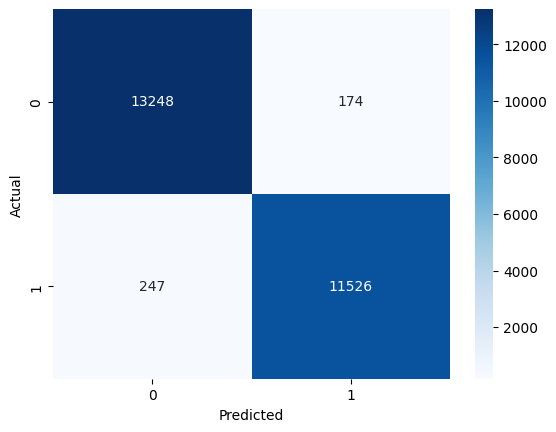

In [4]:
print("Training 1D CNN Model...")
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test))

# Evaluate
y_pred_probs = model.predict(X_test)
# Convert continuous soft probabilities back to definitive categorical hard predictions
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("\n--- CNN Classification Report ---")
print_metrics(y_true_classes, y_pred_classes)

plot_confusion(y_true_classes, y_pred_classes)